# 01 · Why the two obvious designs fail

**What this notebook answers.** Two of my advisor's meeting notes, and one question asked
directly:

> *"Bunching just above the reporting threshold exists across sectors when comparing
> always-covered and threshold-bound firms."*

> *"Besides emissions, are there any systematic differences between treated firms
> (threshold-bound) and 'counterfactual' firms (always-covered)?"*

A reader coming to this setting reaches for one of two designs:

| design | idea | verdict |
|---|---|---|
| **A** | bunching in the level density at 25,000 | ✗ the shape is **truncation**, not behaviour |
| **B** | always-covered facilities as the counterfactual density | ✗ fails its own validity check |

Both fail, and for the same underlying reason: **threshold-bound facilities are not
observed below 25,000**. This notebook establishes that carefully, because everything
in notebooks 02 and 03 is a way of working around it.

It ends with something useful, though: always-covered facilities fail as a
*counterfactual* (a strong requirement) but work as a *placebo* (a weak one). Notebook
02 uses them that way throughout.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

sys.path.insert(0, ".")
from ghgrp_load import load_cached

OUT = Path("output")
de = load_cached()
K_LOG = np.log(25000)
print(f"{len(de):,} facility-years | {de.FacilityId.nunique():,} facilities")

94,378 facility-years | 8,778 facilities


## 1 · Design A — the pile-up above 25,000 is truncation

**The decisive test.** Always-covered facilities (subparts D/F/G/H/HH) report
*regardless of level*. They are therefore **not truncated at 25,000**. If the number
25,000 had any behavioural pull of its own — a salience effect, a norm, a fear of
scrutiny — it should show up in this group too, because they can be observed on both
sides of it.

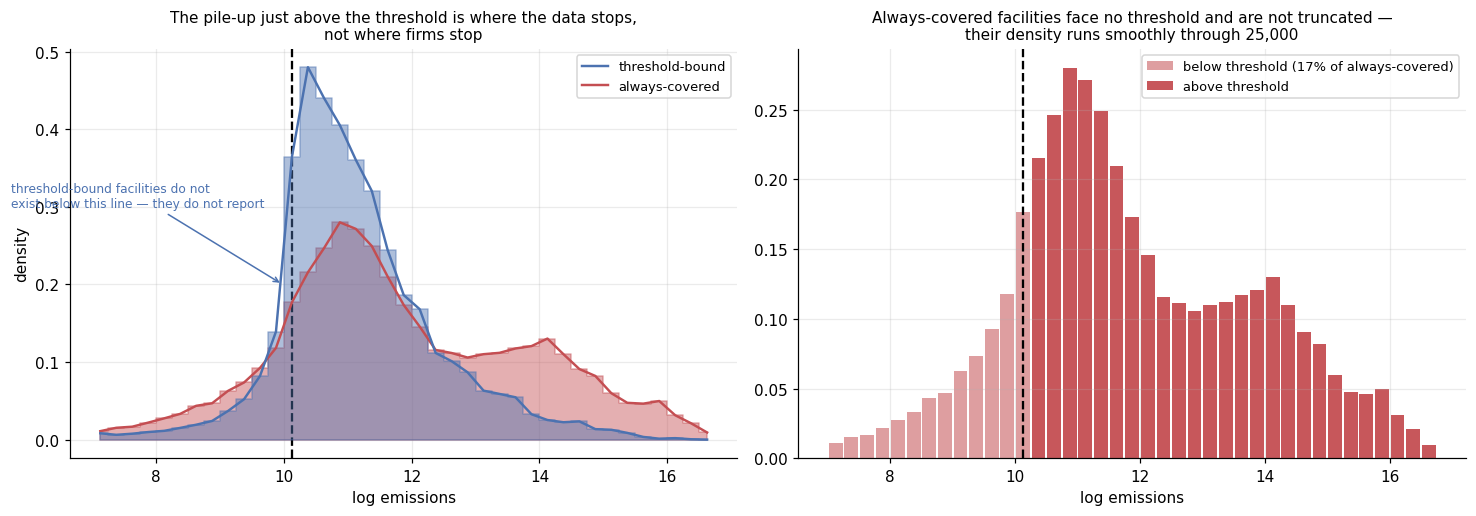

always-covered observations below 25,000: 5,851 (16.9%)


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
bins = np.arange(7, 17, .25)

for grp, lab, c, z in [(de.threshold_bound, "threshold-bound", "#4C72B0", 3),
                       (de.always_covered, "always-covered", "#C44E52", 2)]:
    s = np.log(de.loc[grp & (de.emissions > 0), "emissions"])
    h, e = np.histogram(s, bins=bins, density=True)
    ax[0].fill_between(e[:-1] + .125, h, alpha=.45, color=c, step="mid", zorder=z)
    ax[0].plot(e[:-1] + .125, h, color=c, lw=1.6, label=lab, zorder=z + 1)
ax[0].axvline(K_LOG, color="k", ls="--", lw=1.5)
ax[0].annotate("threshold-bound facilities do not\nexist below this line — they do not report",
               (K_LOG - .15, .20), xytext=(K_LOG - 4.4, .30), fontsize=8, color="#4C72B0",
               arrowprops=dict(arrowstyle="->", color="#4C72B0", lw=1))
ax[0].set_xlabel("log emissions"); ax[0].set_ylabel("density"); ax[0].legend(fontsize=8.5)
ax[0].set_title("The pile-up just above the threshold is where the data stops,\n"
                "not where firms stop", fontsize=10)

s = np.log(de.loc[de.always_covered & (de.emissions > 0), "emissions"])
h, e = np.histogram(s, bins=bins, density=True); below = (e[:-1] + .125) < K_LOG
ax[1].bar((e[:-1] + .125)[below], h[below], width=.22, color="#C44E52", alpha=.55,
          label=f"below threshold ({(s < K_LOG).mean():.0%} of always-covered)")
ax[1].bar((e[:-1] + .125)[~below], h[~below], width=.22, color="#C44E52", alpha=.95,
          label="above threshold")
ax[1].axvline(K_LOG, color="k", ls="--", lw=1.5); ax[1].legend(fontsize=8.5)
ax[1].set_xlabel("log emissions")
ax[1].set_title("Always-covered facilities face no threshold and are not truncated —\n"
                "their density runs smoothly through 25,000", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "f14_truncation_not_bunching.png", bbox_inches="tight")
plt.show()

print(f"always-covered observations below 25,000: {(s < K_LOG).sum():,} ({(s < K_LOG).mean():.1%})")

### Testing that formally rather than by eye

A raw bin-count ratio across the cutoff is not the right statistic: the always-covered
density is *rising* through 25,000 (their median is around 133,000), so more mass above
than below is exactly what a smooth density produces. The question is whether there is a
**step**, which is what `rddensity` tests.

Run it on the always-covered group at the real threshold and at five placebo cutoffs.

In [3]:
from rddensity import rddensity

x = de.loc[de.always_covered & de.emissions.between(5_000, 100_000), "emissions"].values
print(f"always-covered facility-years in [5,000, 100,000]: {len(x):,}\n")

rows = []
for c in [25_000, 15_000, 20_000, 30_000, 35_000, 40_000]:
    for spec in ["unrestricted", "restricted"]:
        r = rddensity(X=x, c=c, fitselect=spec)
        fl, fr = r.hat["left"], r.hat["right"]
        rows.append(dict(cutoff=c, spec=spec,
                         n_left=int(((x >= c - 5000) & (x < c)).sum()),
                         n_right=int(((x >= c) & (x < c + 5000)).sum()),
                         rel_jump=(fr - fl) / fl if fl > 0 else np.nan,
                         t=r.test["t_jk"], p=r.test["p_jk"], sig=r.test["p_jk"] < 0.05))
AC = pd.DataFrame(rows)
AC.to_csv(OUT / "t12_always_covered_density.csv", index=False)
display(AC.round(3))

always-covered facility-years in [5,000, 100,000]: 16,119



,cutoff,spec,n_left,n_right,rel_jump,t,p,sig
0,25000,unrestricted,1148,1209,-0.078,-0.702,0.483,False
1,25000,restricted,1148,1209,0.137,2.410,0.016,True
2,15000,unrestricted,1052,1015,-0.148,-1.090,0.276,False
3,15000,restricted,1052,1015,-0.067,-0.984,0.325,False
4,20000,unrestricted,1015,1148,-0.187,-1.510,0.131,False
5,20000,restricted,1015,1148,0.210,3.255,0.001,True
6,30000,unrestricted,1209,1163,0.208,1.869,0.062,False
7,30000,restricted,1209,1163,-0.040,-0.702,0.483,False
8,35000,unrestricted,1163,1018,-0.071,-0.518,0.604,False
9,35000,restricted,1163,1018,-0.158,-2.813,0.005,True


### ★ Result

| cutoff | rel. jump | t | p |
|---|---|---|---|
| **25,000 (the real threshold)** | **−0.078** | **−0.70** | **0.48** |
| 15,000 | −0.148 | −1.09 | 0.28 |
| 20,000 | −0.187 | −1.51 | 0.13 |
| 30,000 | +0.208 | +1.87 | 0.06 |
| 35,000 | −0.071 | −0.52 | 0.60 |
| 40,000 | −0.058 | −0.42 | 0.68 |

**No discontinuity at 25,000, and none at any placebo cutoff either** — the density of the
unconstrained group passes through the threshold like any other point in its support.

⚠️ The *restricted* specification rejects at 20,000 (p = 0.001) and 35,000 (p = 0.005) but
not at 25,000 — the same pattern of uninformative rejections that appears in the state
panels (notebook 02 §6). The default specification is the one to read.

⚠️ A note on an earlier version of this test. I first reported a raw bin-count ratio of
"0.96–0.97 across the cutoff". That number was wrong — it had been carried over from the
dominated-region test in notebook 02, which measures something else. The actual raw ratios
are 1.14 (NAICS 221) and 1.46 (NAICS 562), and they are *supposed* to exceed one, because
the density is rising through 25,000. **A raw ratio cannot answer this question; only a
discontinuity test can.** The table above is the corrected version.

### ★ Verdict on design A

**16.9% of always-covered facility-years sit below 25,000, and their density has no
discontinuity there** — `rddensity` t = −0.70, p = 0.48, with the same null at all five
placebo cutoffs.

> If 25,000 exerted any pull as a *number*, this group would show it. It does not.
> **The tall bar in the threshold-bound density is where the data stops, not where
> firms stop.**

**How to put this to my advisor.** Not "you misread the figure" — the figure genuinely looks
like bunching. Rather:

> *Always-covered facilities face no threshold and 17% of them sit below 25,000, with a
> density that runs straight through it. Am I right that this points to truncation
> rather than behaviour?*

⚠️ Note what this does **not** rule out: manipulation by threshold-bound facilities that
is invisible because the manipulators leave the sample. That is exactly what notebook 02
goes after, by moving into growth-rate space and then into state data.

## 2 · Design B — always-covered as a counterfactual density

The standard move would be: rescale the always-covered density to match the
threshold-bound density *above* the cutoff, extrapolate below, and call the shortfall
"missing mass". That requires the two groups to share a **shape**.

**The validity check writes itself**: compare the two distributions in the region where
*both* are fully observed — above 25,000. If they do not match there, the extrapolation
below is not credible.

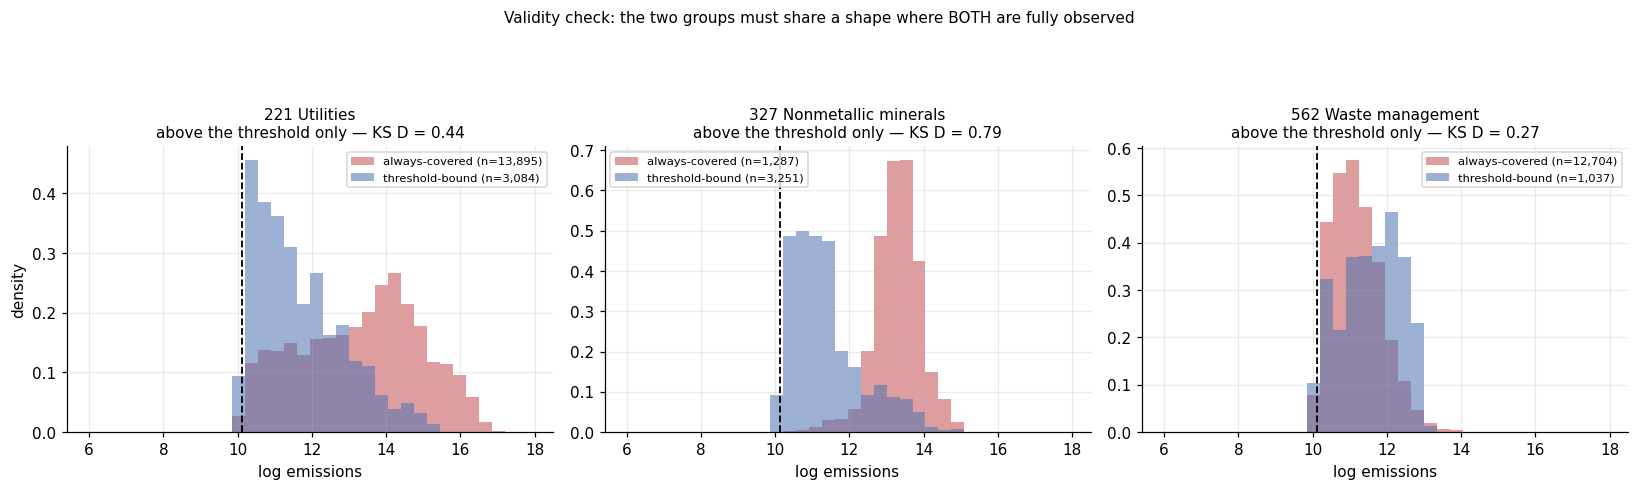

,naics3,n_always,n_bound,median_gap,ks_D,ks_p
0,221,13895,3084,2.10,0.443,0.0e+00
1,327,1287,3251,2.15,0.795,5.6e-322
2,562,12704,1037,-0.52,0.265,6.0e-60


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
rows = []
for a, (s_, name) in zip(ax, [("221", "221 Utilities"), ("327", "327 Nonmetallic minerals"),
                              ("562", "562 Waste management")]):
    d = de[(de.naics3 == s_) & (de.emissions > 0)]
    A = np.log(d.loc[d.always_covered, "emissions"]);  A = A[A > K_LOG]
    B = np.log(d.loc[d.threshold_bound, "emissions"]); B = B[B > K_LOG]
    ks = stats.ks_2samp(A, B)
    rows.append(dict(naics3=s_, n_always=len(A), n_bound=len(B),
                     median_gap=round(A.median() - B.median(), 2),
                     ks_D=round(ks.statistic, 3), ks_p=f"{ks.pvalue:.1e}"))
    b = np.arange(6, 18, .35)
    a.hist(A, bins=b, density=True, alpha=.55, color="#C44E52", label=f"always-covered (n={len(A):,})")
    a.hist(B, bins=b, density=True, alpha=.55, color="#4C72B0", label=f"threshold-bound (n={len(B):,})")
    a.axvline(K_LOG, color="k", ls="--", lw=1.2)
    a.set_title(f"{name}\nabove the threshold only — KS D = {ks.statistic:.2f}", fontsize=10)
    a.set_xlabel("log emissions"); a.legend(fontsize=7.5)
ax[0].set_ylabel("density")
fig.suptitle("Validity check: the two groups must share a shape where BOTH are fully observed",
             fontsize=10)
plt.tight_layout(rect=[0, 0, 1, .88])
plt.savefig(OUT / "f11_counterfactual_check.png", bbox_inches="tight"); plt.show()
val = pd.DataFrame(rows); val.to_csv(OUT / "t5_counterfactual_validity.csv", index=False)
display(val)

**All three sectors reject equality decisively.** Within the *same* three-digit
industry, always-covered facilities are roughly an order of magnitude larger.

The most forgiving case is waste management (562), where the two groups are closest.
Run the counterfactual there anyway and see how it does **on the region it was fitted
on** — a fit that cannot reproduce its own training region certainly cannot extrapolate.

In [5]:
d = de[(de.naics3 == "562") & (de.emissions > 0)]
A = np.log(d.loc[d.always_covered, "emissions"]).values
B = np.log(d.loc[d.threshold_bound, "emissions"]).values
bins = np.arange(7.0, 15.0, .25); mid = bins[:-1] + .125; above = mid > K_LOG
hA = np.histogram(A, bins=bins)[0]; hB = np.histogram(B, bins=bins)[0]

scale = hB[above].sum() / max(hA[above].sum(), 1)
cf = hA * scale
fit_err = abs(hB[above] - cf[above]).sum() / hB[above].sum()
print(f"scaling factor fitted above 25,000: {scale:.3f}")
print(f"relative error of that fit ON ITS OWN FITTED REGION: {fit_err:.1%}")
print(f"\nimplied 'missing' mass below the threshold: "
      f"{cf[~above].sum() - hB[~above].sum():,.0f}  <- do not report this number")

scaling factor fitted above 25,000: 0.081
relative error of that fit ON ITS OWN FITTED REGION: 57.1%

implied 'missing' mass below the threshold: 179  <- do not report this number


### ★ Verdict on design B

**The counterfactual misses by 57% on the very region it was fitted to.** Any "missing
mass" it produces below the threshold is an artefact of shape mismatch, not evidence of
manipulation. Design B is unusable.

## 3 · The balance table — my advisor asked for this directly

> *"Besides emissions, are there any systematic differences between treated firms and
> 'counterfactual' firms?"*

Imbens–Rubin normalized differences; |ND| > 0.25 is the conventional flag for serious
imbalance.

In [6]:
TB = de[de.threshold_bound]; AC = de[de.always_covered]
print(f"threshold-bound  {len(TB):>7,} facility-years  /  {TB.FacilityId.nunique():>5,} facilities")
print(f"always-covered   {len(AC):>7,} facility-years  /  {AC.FacilityId.nunique():>5,} facilities\n")


def norm_diff(a, b):
    a = pd.to_numeric(a, errors="coerce").dropna(); b = pd.to_numeric(b, errors="coerce").dropna()
    if len(a) < 2 or len(b) < 2: return np.nan
    s = np.sqrt((a.var() + b.var()) / 2)
    return (a.mean() - b.mean()) / s if s > 0 else np.nan


rows = []


def add(name, a, b):
    rows.append(dict(variable=name, tb_mean=a.mean(), tb_sd=a.std(),
                     ac_mean=b.mean(), ac_sd=b.std(), norm_diff=norm_diff(a, b)))


add("Emissions (tCO2e)", TB.emissions, AC.emissions)
add("log Emissions", TB.log_em, AC.log_em)
add("Subparts reported", TB.n_subparts, AC.n_subparts)
add("CEMS (=1)", TB.cems.astype(float), AC.cems.astype(float))
add("Latitude", TB.lat, AC.lat)
add("Longitude", TB.lon, AC.lon)
add("First year in panel", TB.first_year, AC.first_year)
add("Years observed", TB.n_years, AC.n_years)
add("Exits (=1)", TB.exits.astype(float), AC.exits.astype(float))
add("Enters (=1)", TB.enters.astype(float), AC.enters.astype(float))
for gas, lab in [("CO2 emissions (non-biogenic)", "CO2 share of emissions"),
                 ("Methane (CH4) emissions", "CH4 share of emissions"),
                 ("Nitrous Oxide (N2O) emissions", "N2O share of emissions")]:
    if gas in de.columns:
        add(lab, (pd.to_numeric(TB[gas], errors="coerce") / TB.emissions).clip(0, 1),
                 (pd.to_numeric(AC[gas], errors="coerce") / AC.emissions).clip(0, 1))

B_ = pd.DataFrame(rows); B_["abs_ND"] = B_.norm_diff.abs()
B_ = B_.sort_values("abs_ND", ascending=False)
B_.to_csv(OUT / "t9_balance_table.csv", index=False)
display(B_.round(3))
print(f"\n|ND| > 0.25 : {(B_.abs_ND > 0.25).sum()} of {B_.abs_ND.notna().sum()} variables")

threshold-bound   59,607 facility-years  /  5,951 facilities
always-covered    34,771 facility-years  /  2,918 facilities



,variable,tb_mean,tb_sd,ac_mean,ac_sd,norm_diff,abs_ND
11,CH4 share of emissions,0.083,0.208,0.473,0.496,-1.025,1.025
10,CO2 share of emissions,0.916,0.200,0.709,0.445,0.598,0.598
0,Emissions (tCO2e),184762.768,538597.425,814036.132,1977241.670,-0.434,0.434
1,log Emissions,11.057,1.406,11.798,2.013,-0.427,0.427
6,First year in panel,2010.927,2.197,2010.226,1.169,0.398,0.398
7,Years observed,12.039,3.225,13.123,2.359,-0.384,0.384
3,CEMS (=1),0.018,0.135,0.082,0.274,-0.294,0.294
9,Enters (=1),0.038,0.191,0.007,0.081,0.214,0.214
5,Longitude,-93.257,17.052,-91.667,14.950,-0.099,0.099
8,Exits (=1),0.030,0.170,0.015,0.123,0.098,0.098



|ND| > 0.25 : 7 of 13 variables


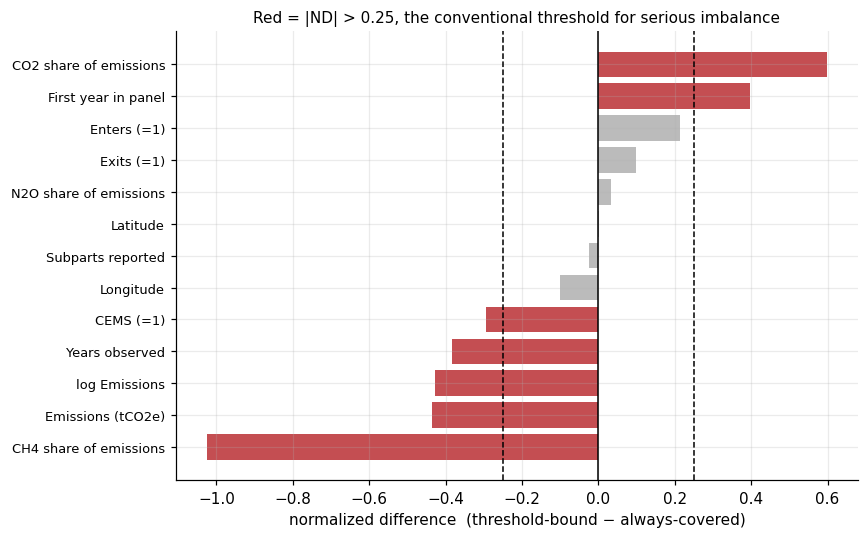

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
b = B_.dropna(subset=["norm_diff"]).sort_values("norm_diff")
cols = ["#C44E52" if abs(v) > 0.25 else "#BBBBBB" for v in b.norm_diff]
ax.barh(range(len(b)), b.norm_diff, color=cols)
ax.set_yticks(range(len(b))); ax.set_yticklabels(b.variable, fontsize=8.5)
for x in (-.25, .25): ax.axvline(x, color="k", ls="--", lw=1)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("normalized difference  (threshold-bound − always-covered)")
ax.set_title("Red = |ND| > 0.25, the conventional threshold for serious imbalance", fontsize=10)
plt.tight_layout(); plt.savefig(OUT / "f17_balance.png", bbox_inches="tight"); plt.show()

In [8]:
comp = (pd.crosstab(de.naics3, de.threshold_bound, normalize="columns")
          .rename(columns={True: "threshold-bound", False: "always-covered"}))
comp["difference"] = comp["threshold-bound"] - comp["always-covered"]
top = comp.reindex(comp.abs().max(axis=1).sort_values(ascending=False).index).head(12)
display((top * 100).round(1))

print("\nshare of each group in its two largest sectors:")
for lab, grp in [("threshold-bound", de[de.threshold_bound]), ("always-covered", de[de.always_covered])]:
    v = grp.naics3.value_counts(normalize=True).head(2)
    print(f"  {lab:<17} " + "  ".join(f"{i}: {x:.0%}" for i, x in v.items()))

threshold_bound,always-covered,threshold-bound,difference
naics3,,,
221,46.8,7.2,-39.7
562,46.8,1.9,-44.9
211,0.0,15.0,14.9
325,1.2,14.6,13.4
486,0.0,14.5,14.5
311,0.0,7.7,7.7
331,0.4,6.2,5.9
327,3.8,5.9,2.1
322,0.0,5.3,5.3



share of each group in its two largest sectors:


  threshold-bound   211: 15%  325: 15%
  always-covered    221: 47%  562: 47%


### ★ What the balance table actually shows

**7 of 13 variables exceed |ND| = 0.25.** And the worst imbalance is *not* size:

> **the methane share of emissions, ND = −1.03.** Always-covered facilities are 47%
> methane (landfills, subpart HH); threshold-bound facilities are 8%.

The two groups are not the same production process at different scales. **They are
different production processes.**

**How to write this up.** The table's purpose is not to show the groups are comparable —
they demonstrably are not. Its purpose is to **document the specific dimensions on which
they differ**, so the paper can say precisely why always-covered cannot be a
counterfactual. That is an appendix table a referee will want regardless.

### ★★ But the same group is still useful — as a placebo

| | requirement | satisfied? |
|---|---|---|
| **counterfactual** | same shape as the treated group absent treatment | ✗ (§2, §3) |
| **placebo** | *not* subject to the treatment | ✓ by construction |

A placebo does not require the groups to be similar. It only requires that the placebo
group be **unexposed to the incentive**. Always-covered facilities gain nothing by
crossing 25,000 — they report either way — so they are a valid placebo even though they
are a hopeless counterfactual.

⚠️ One definitional trap worth recording, because I fell into it: always-covered is
defined by **subpart, not by level**. It is *not* true that these facilities are all far
above 25,000 (17% are below it, p10 = 12,942). The reason they have no incentive to
manipulate is that **crossing the line buys them nothing**, not that they are too big to
cross it.

---
### → Continue in **02_no_manipulation**

Both level-based designs are dead. Notebook 02 moves the question into **growth-rate
space**, where both sides of the cutoff are observed, uses always-covered as a placebo
throughout, and then goes to **California and Washington** — which require reporting
from 10,000 tCO₂e and therefore observe the region the federal data cannot.